# 🇲🇦 Prédicteur de Performance YouTube Marocain
## Modèle ML Commercialisable — XGBoost vs Random Forest

**Objectif :** Prédire le niveau de performance d'une vidéo YouTube marocaine  
avant publication, à partir de ses caractéristiques éditoriales.

**Cible :** Classification multi-classes — 4 niveaux de performance :
- 🔘 **Correct** (< Q1 du marché)  
- 🔵 **Bon** (Q1–Q2, autour de la médiane)  
- 🟠 **Super** (Q2–Q3, au-dessus du standard)  
- 🔴 **Viral** (≥ Q3, top 25%)

**Structure :**
1. Chargement & préparation du dataset  
2. Feature Engineering avancé  
3. Entraînement XGBoost vs Random Forest  
4. Comparaison & métriques  
5. Feature Importance & SHAP  
6. Outil de prédiction commercialisable  
7. Export du modèle final

## 0. Imports & Configuration

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score,
                              ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb
    print("XGBoost installé:", xgb.__version__)

try:
    import shap
    print("SHAP version:", shap.__version__)
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
    print("SHAP installé")

import joblib
import os

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

PERF_ORDER  = ['Correct', 'Bon', 'Super', 'Viral']
PERF_COLORS = {'Correct': '#B0BEC5', 'Bon': '#64B5F6', 'Super': '#FFB74D', 'Viral': '#EF5350'}

print("✅ Imports OK")

XGBoost version: 2.1.4
SHAP version: 0.49.1
✅ Imports OK


## 1. Chargement du Dataset

In [10]:
# Chargement du dataset enrichi (depuis AnalyseMorWeb_v6)
df = pd.read_csv("../data/scrapping/df_benchmark_clean.csv")
df['publishedAt'] = pd.to_datetime(df['publishedAt'], utc=True)

print(f"Dataset chargé : {len(df):,} vidéos | {df['channelTitle'].nunique()} créateurs")
print(f"Colonnes disponibles : {df.shape[1]}")
print()

# ── Re-calcul des seuils Q1/Q2/Q3 (identique v6) ──────────────────────────
q1_global = df['viewCount'].quantile(0.25)
q2_global = df['viewCount'].quantile(0.50)
q3_global = df['viewCount'].quantile(0.75)

print("Seuils du marché marocain :")
print(f"  Q1 (Correct) : {q1_global:>10,.0f} vues")
print(f"  Q2 (Bon)     : {q2_global:>10,.0f} vues  ← médiane = standard marché")
print(f"  Q3 (Super)   : {q3_global:>10,.0f} vues")

def classify_performance(views):
    if views >= q3_global:   return 'Viral'
    elif views >= q2_global: return 'Super'
    elif views >= q1_global: return 'Bon'
    else:                    return 'Correct'

df['performance_label'] = df['viewCount'].apply(classify_performance)

print()
print("Distribution des classes :")
for level in PERF_ORDER:
    n   = (df['performance_label'] == level).sum()
    pct = n / len(df) * 100
    print(f"  {level:<8} : {n:>5}  ({pct:.1f}%)")

Dataset chargé : 8,651 vidéos | 26 créateurs
Colonnes disponibles : 40

Seuils du marché marocain :
  Q1 (Correct) :    216,243 vues
  Q2 (Bon)     :    478,807 vues  ← médiane = standard marché
  Q3 (Super)   :  1,117,032 vues

Distribution des classes :
  Correct  :  2163  (25.0%)
  Bon      :  2162  (25.0%)
  Super    :  2163  (25.0%)
  Viral    :  2163  (25.0%)


## 2. Feature Engineering pour le ML

In [11]:
# ─── Features temporelles ────────────────────────────────────────────────
if 'publish_hour' not in df.columns:
    df['publish_hour']       = df['publishedAt'].dt.hour
    df['publish_day_of_week']= df['publishedAt'].dt.dayofweek
    df['publish_month']      = df['publishedAt'].dt.month
    df['publish_year']       = df['publishedAt'].dt.year

# Heure créneau (catégorielle)
def hour_slot(h):
    if   h < 6:  return 'nuit'
    elif h < 12: return 'matin'
    elif h < 18: return 'aprem'
    else:        return 'soir'
df['hour_slot'] = df['publish_hour'].apply(hour_slot)

# Fin de semaine
df['is_weekend'] = df['publish_day_of_week'].isin([5, 6]).astype(int)

# ─── Features de contenu ─────────────────────────────────────────────────
if 'title_word_count' not in df.columns:
    df['title_word_count']   = df['videoTitle'].fillna('').apply(lambda x: len(x.split()))
    df['title_char_count']   = df['videoTitle'].fillna('').apply(len)
    df['title_has_number']   = df['videoTitle'].fillna('').str.contains(r'[0-9]').astype(int)
    df['title_has_question'] = df['videoTitle'].fillna('').str.contains(r'[?]').astype(int)
else:
    df['title_has_number']   = df['title_has_number'].astype(int)
    df['title_has_question'] = df['title_has_question'].astype(int)

if 'tags_count' not in df.columns:
    df['tags_count'] = df['tags'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)

# Durée en minutes
df['duration_min'] = df['durationSec'] / 60

# ─── Features par chaîne (stats historiques = "réputation de la chaîne") ──
channel_stats = df.groupby('channelTitle').agg(
    chan_median_views   =('viewCount',       'median'),
    chan_mean_views     =('viewCount',       'mean'),
    chan_std_views      =('viewCount',       'std'),
    chan_total_videos   =('videoId',         'count'),
    chan_engagement_med =('engagement_rate', 'median'),
).fillna(0)
channel_stats['chan_cv'] = (channel_stats['chan_std_views'] /
                            channel_stats['chan_mean_views'].replace(0, 1)).round(3)
channel_stats['chan_consistency'] = (1 / (1 + channel_stats['chan_cv'])).round(3)

df = df.merge(channel_stats.reset_index(), on='channelTitle', how='left')

# ─── Feature "position dans le temps" (maturation chaîne) ─────────────────
df_sorted = df.sort_values(['channelTitle', 'publishedAt'])
df['video_rank_in_channel'] = df_sorted.groupby('channelTitle').cumcount() + 1

# ─── Encodage duration_category ordinal ──────────────────────────────────
dur_order = ['Short (moins 1min)', 'Court (1-5min)', 'Moyen (5-20min)', 'Long (plus 20min)']
dur_map   = {v: i for i, v in enumerate(dur_order)}
df['duration_ord'] = df['duration_category'].map(dur_map).fillna(1)

# ─── Ramadan ──────────────────────────────────────────────────────────────
if 'is_ramadan' in df.columns:
    df['is_ramadan'] = df['is_ramadan'].astype(int)
else:
    df['is_ramadan'] = 0

print("✅ Feature Engineering terminé")
print(f"   Colonnes totales : {df.shape[1]}")

✅ Feature Engineering terminé
   Colonnes totales : 52


## 3. Préparation X / y pour les modèles

In [12]:
# ─── Features sélectionnées pour le modèle ────────────────────────────────
FEATURE_COLS = [
    # Contenu éditorial
    'duration_min', 'duration_ord',
    'title_word_count', 'title_char_count', 'title_has_number', 'title_has_question',
    'tags_count',
    # Temporel
    'publish_hour', 'publish_day_of_week', 'publish_month', 'is_weekend', 'is_ramadan',
    # Thème & langue (encodés)
    'theme_video', 'langue', 'videoCategoryLabel', 'hour_slot',
    # Réputation de la chaîne
    'chan_median_views', 'chan_mean_views', 'chan_consistency',
    'chan_total_videos', 'chan_engagement_med', 'video_rank_in_channel',
]

TARGET_COL = 'performance_label'

# ─── Filtrage des colonnes existantes ────────────────────────────────────
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f"Features utilisées : {len(FEATURE_COLS)}")
for f in FEATURE_COLS:
    print(f"  · {f}")

# ─── Encodage des variables catégorielles ────────────────────────────────
cat_cols = ['theme_video', 'langue', 'videoCategoryLabel', 'hour_slot']
cat_cols = [c for c in cat_cols if c in FEATURE_COLS]

df_ml = df[FEATURE_COLS + [TARGET_COL]].copy()

# Label encoder pour chaque cat col
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].fillna('unknown').astype(str))
    le_dict[col] = le

# Cible ordinale
label_order = {v: i for i, v in enumerate(PERF_ORDER)}
df_ml['target_ord'] = df_ml[TARGET_COL].map(label_order)

X = df_ml[FEATURE_COLS].astype(float)
y = df_ml['target_ord'].astype(int)

# ─── Split stratifié ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print()
print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")
print()
print("Distribution train/test :")
for i, level in enumerate(PERF_ORDER):
    n_tr = (y_train == i).sum()
    n_te = (y_test  == i).sum()
    print(f"  {level:<8}  train={n_tr:>4}  test={n_te:>4}")

Features utilisées : 22
  · duration_min
  · duration_ord
  · title_word_count
  · title_char_count
  · title_has_number
  · title_has_question
  · tags_count
  · publish_hour
  · publish_day_of_week
  · publish_month
  · is_weekend
  · is_ramadan
  · theme_video
  · langue
  · videoCategoryLabel
  · hour_slot
  · chan_median_views
  · chan_mean_views
  · chan_consistency
  · chan_total_videos
  · chan_engagement_med
  · video_rank_in_channel

Train : 6,920 | Test : 1,731

Distribution train/test :
  Correct   train=1730  test= 433
  Bon       train=1730  test= 432
  Super     train=1730  test= 433
  Viral     train=1730  test= 433


## 4. Modèle Random Forest

In [13]:
# ─── Class weights pour gérer le déséquilibre ─────────────────────────────
classes    = np.unique(y_train)
weights    = compute_class_weight('balanced', classes=classes, y=y_train.values)
cw_dict    = dict(zip(classes, weights))
print("Class weights (balanced) :", {PERF_ORDER[k]: round(v,2) for k,v in cw_dict.items()})

# ─── Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 18,
    min_samples_leaf = 4,
    max_features     = 'sqrt',
    class_weight     = cw_dict,
    random_state     = 42,
    n_jobs           = -1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')

print()
print(f"Random Forest — Accuracy : {acc_rf:.4f}  |  F1 weighted : {f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf,
                             target_names=PERF_ORDER, digits=3))

Class weights (balanced) : {'Correct': np.float64(1.0), 'Bon': np.float64(1.0), 'Super': np.float64(1.0), 'Viral': np.float64(1.0)}

Random Forest — Accuracy : 0.6574  |  F1 weighted : 0.6533

              precision    recall  f1-score   support

     Correct      0.724     0.811     0.765       433
         Bon      0.570     0.593     0.581       432
       Super      0.569     0.476     0.518       433
       Viral      0.747     0.751     0.749       433

    accuracy                          0.657      1731
   macro avg      0.653     0.657     0.653      1731
weighted avg      0.653     0.657     0.653      1731



## 5. Modèle XGBoost

In [14]:
# ─── XGBoost ──────────────────────────────────────────────────────────────
# Calcul du scale_pos_weight adapté (multi-class via sample_weight)
from sklearn.utils import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators      = 400,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    objective         = 'multi:softprob',
    num_class         = 4,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

xgb_model.fit(
    X_train, y_train,
    sample_weight    = sample_weights,
    eval_set         = [(X_test, y_test)],
    verbose          = False
)

y_pred_xgb = xgb_model.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"XGBoost — Accuracy : {acc_xgb:.4f}  |  F1 weighted : {f1_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb,
                             target_names=PERF_ORDER, digits=3))

XGBoost — Accuracy : 0.6661  |  F1 weighted : 0.6648

              precision    recall  f1-score   support

     Correct      0.778     0.811     0.794       433
         Bon      0.582     0.627     0.604       432
       Super      0.549     0.501     0.524       433
       Viral      0.749     0.725     0.737       433

    accuracy                          0.666      1731
   macro avg      0.665     0.666     0.665      1731
weighted avg      0.665     0.666     0.665      1731



## 6. Comparaison XGBoost vs Random Forest

Cross-validation F1 weighted (5-fold) :
  Random Forest  : 0.6637  ±  0.0065  | scores : [0.663 0.667 0.671 0.652 0.666]
  XGBoost        : 0.6633  ±  0.0050  | scores : [0.669 0.664 0.667 0.663 0.654]



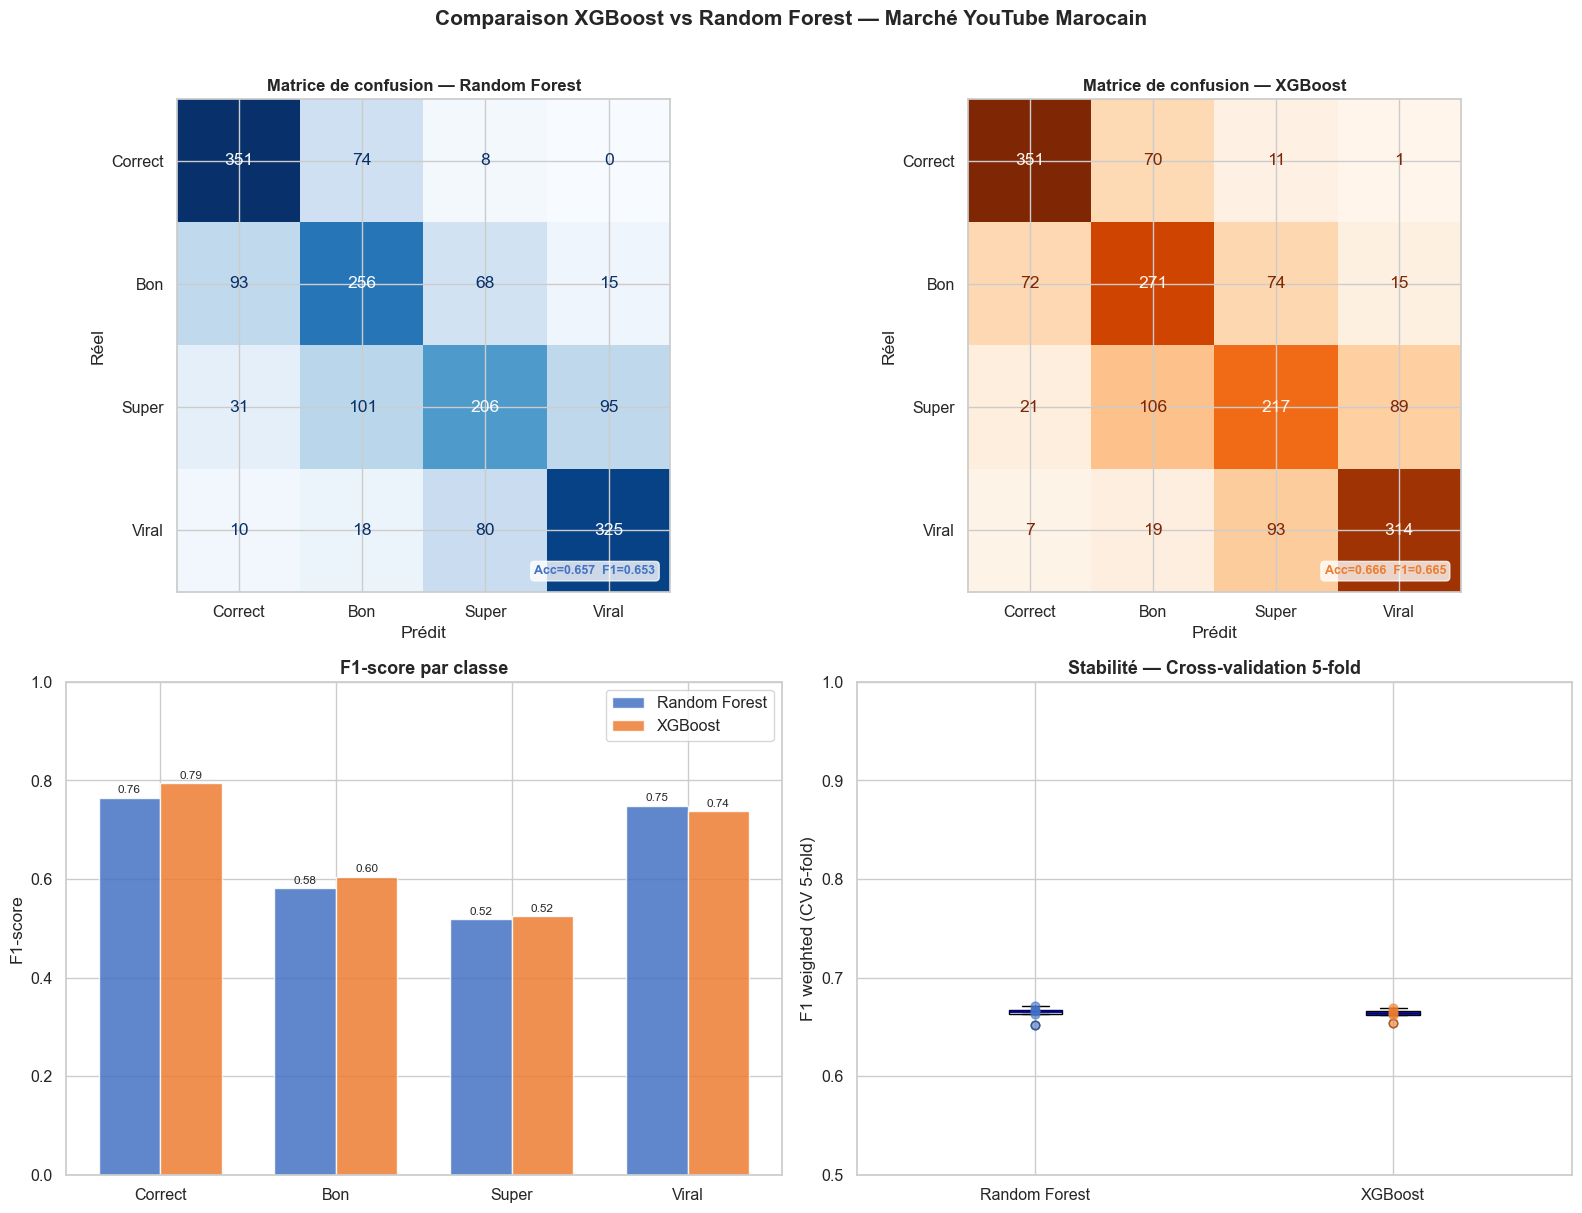


   SYNTHÈSE COMPARATIVE
  Métrique                    Random Forest         XGBoost
  -------------------------------------------------------
  Accuracy (test)                  0.6574             0.6661  ← ✅
  F1 weighted (test)               0.6533             0.6648  ← ✅
  F1 CV mean (5-fold)              0.6637  ← ✅        0.6633     
  F1 CV std  (5-fold)              0.0065             0.0050  ← ✅


In [15]:
# ─── Cross-validation 5-fold ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rf  = cross_val_score(rf,        X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
cv_xgb = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)

print("Cross-validation F1 weighted (5-fold) :")
print(f"  Random Forest  : {cv_rf.mean():.4f}  ±  {cv_rf.std():.4f}  | scores : {cv_rf.round(3)}")
print(f"  XGBoost        : {cv_xgb.mean():.4f}  ±  {cv_xgb.std():.4f}  | scores : {cv_xgb.round(3)}")
print()

# ─── Figure comparaison 2×2 ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparaison XGBoost vs Random Forest — Marché YouTube Marocain",
             fontsize=15, fontweight='bold', y=1.01)

# 1. Matrices de confusion
for ax, y_pred, title, cmap in [
    (axes[0,0], y_pred_rf,  "Random Forest",  "Blues"),
    (axes[0,1], y_pred_xgb, "XGBoost",        "Oranges"),
]:
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=PERF_ORDER).plot(
        ax=ax, cmap=cmap, colorbar=False
    )
    ax.set_title(f"Matrice de confusion — {title}", fontsize=12)
    ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")

# 2. F1 par classe
f1_rf_per  = f1_score(y_test, y_pred_rf,  average=None)
f1_xgb_per = f1_score(y_test, y_pred_xgb, average=None)

x_pos = np.arange(len(PERF_ORDER))
w = 0.35
axes[1,0].bar(x_pos - w/2, f1_rf_per,  w, label='Random Forest', color='#4472C4', alpha=0.85)
axes[1,0].bar(x_pos + w/2, f1_xgb_per, w, label='XGBoost',       color='#ED7D31', alpha=0.85)
axes[1,0].set_xticks(x_pos); axes[1,0].set_xticklabels(PERF_ORDER)
axes[1,0].set_ylim(0, 1)
axes[1,0].set_ylabel("F1-score"); axes[1,0].set_title("F1-score par classe")
axes[1,0].legend()
for i, (r, x_) in enumerate(zip(f1_rf_per, x_pos - w/2)):
    axes[1,0].text(x_, r + 0.01, f'{r:.2f}', ha='center', fontsize=8.5)
for i, (x_, x__) in enumerate(zip(f1_xgb_per, x_pos + w/2)):
    axes[1,0].text(x__, x_ + 0.01, f'{x_:.2f}', ha='center', fontsize=8.5)

# 3. CV scores boxplot
axes[1,1].boxplot([cv_rf, cv_xgb],
                  labels=['Random Forest', 'XGBoost'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#D6E4F0'),
                  medianprops=dict(color='navy', linewidth=2))
axes[1,1].scatter([1]*5, cv_rf,  alpha=0.6, color='#4472C4', s=40, zorder=3)
axes[1,1].scatter([2]*5, cv_xgb, alpha=0.6, color='#ED7D31', s=40, zorder=3)
axes[1,1].set_ylabel("F1 weighted (CV 5-fold)")
axes[1,1].set_title("Stabilité — Cross-validation 5-fold")
axes[1,1].set_ylim(0.5, 1.0)

# Annotations métriques finales
for ax, model, acc, f1, color in [
    (axes[0,0], 'RF',  acc_rf,  f1_rf,  '#4472C4'),
    (axes[0,1], 'XGB', acc_xgb, f1_xgb, '#ED7D31'),
]:
    ax.text(0.97, 0.03, f"Acc={acc:.3f}  F1={f1:.3f}",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("../data/scrapping/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ─── Tableau de synthèse ──────────────────────────────────────────────────
print()
print("=" * 55)
print("   SYNTHÈSE COMPARATIVE")
print("=" * 55)
metrics = {
    'Accuracy (test)'      : (acc_rf,          acc_xgb),
    'F1 weighted (test)'   : (f1_rf,            f1_xgb),
    'F1 CV mean (5-fold)'  : (cv_rf.mean(),     cv_xgb.mean()),
    'F1 CV std  (5-fold)'  : (cv_rf.std(),      cv_xgb.std()),
}
print(f"  {'Métrique':<25}  {'Random Forest':>14}  {'XGBoost':>14}")
print("  " + "-" * 55)
for name, (v_rf, v_xgb) in metrics.items():
    winner = "← ✅" if v_xgb > v_rf else ("← ✅" if v_rf > v_xgb else "")
    winner_rf  = "← ✅" if v_rf  > v_xgb else ""
    winner_xgb = "← ✅" if v_xgb > v_rf  else ""
    if 'std' in name:
        winner_xgb = "← ✅" if v_xgb < v_rf else ""
        winner_rf  = "← ✅" if v_rf  < v_xgb else ""
    print(f"  {name:<25}  {v_rf:>12.4f}  {winner_rf:>3}  {v_xgb:>12.4f}  {winner_xgb:>3}")
print("=" * 55)

## 7. Feature Importance & Analyse SHAP

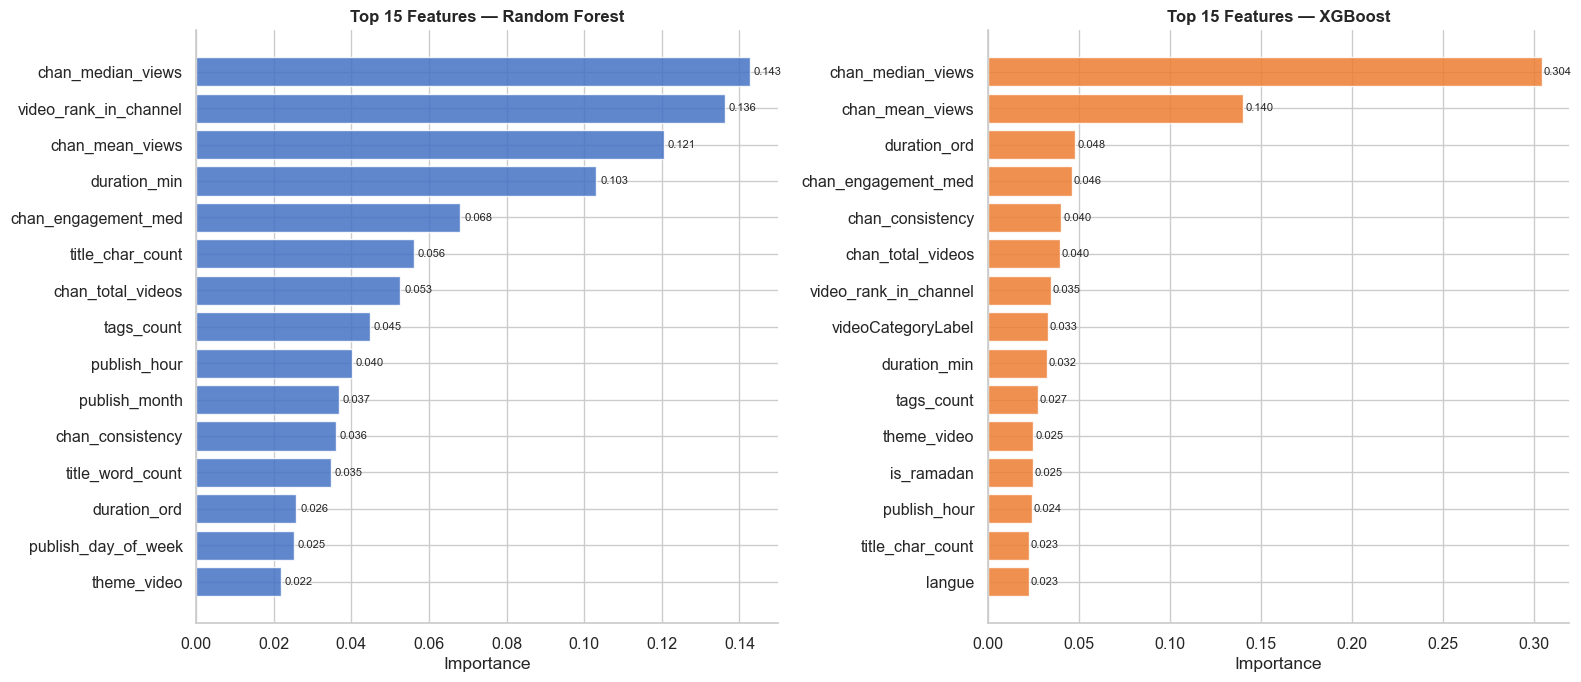

Calcul des valeurs SHAP (XGBoost)...


array([[[-1.07431042e+00,  2.26310730e-01,  2.04519145e-02,
          1.37809232e-01],
        [-1.02287643e-01,  1.96444686e-03,  6.39861375e-02,
          3.57300900e-02],
        [ 4.32320759e-02, -1.45466719e-02,  5.03986850e-02,
         -1.20098136e-01],
        ...,
        [ 8.63691978e-03,  3.16116586e-02, -4.12232094e-02,
         -1.17107496e-01],
        [ 3.83159891e-02,  7.74222836e-02, -8.48845392e-02,
          2.82406397e-02],
        [-4.67657566e-01, -9.36461519e-03, -2.63016932e-02,
          2.46232927e-01]],

       [[-9.77143705e-01, -4.63498205e-01, -2.93011725e-01,
          1.27783144e+00],
        [-6.95129409e-02, -1.72002544e-03,  2.78004189e-03,
          6.16478696e-02],
        [-5.42456731e-02, -5.43637536e-02,  3.80243883e-02,
         -2.36247256e-02],
        ...,
        [ 1.39402613e-01, -8.82824436e-02, -1.37338564e-01,
         -5.63501529e-02],
        [ 2.22494602e-02, -3.31332162e-02, -6.91486523e-02,
          7.91759640e-02],
        [-2.881

In [18]:
# ─── Feature Importance comparée ─────────────────────────────────────────
fi_rf  = pd.Series(rf.feature_importances_,        index=FEATURE_COLS).sort_values(ascending=False)
fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, fi, title, color in [
    (axes[0], fi_rf.head(top_n),  "Random Forest",  '#4472C4'),
    (axes[1], fi_xgb.head(top_n), "XGBoost",        '#ED7D31'),
]:
    bars = ax.barh(fi.index[::-1], fi.values[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top {top_n} Features — {title}", fontsize=12)
    ax.set_xlabel("Importance")
    for bar, val in zip(bars, fi.values[::-1]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../data/scrapping/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# ─── SHAP (sur le meilleur modèle) ────────────────────────────────────────
print("Calcul des valeurs SHAP (XGBoost)...")
explainer  = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap_values

In [25]:
print(shap_values[3][1])

[ 0.23367459 -0.03662908 -0.22305533  0.02343915]


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

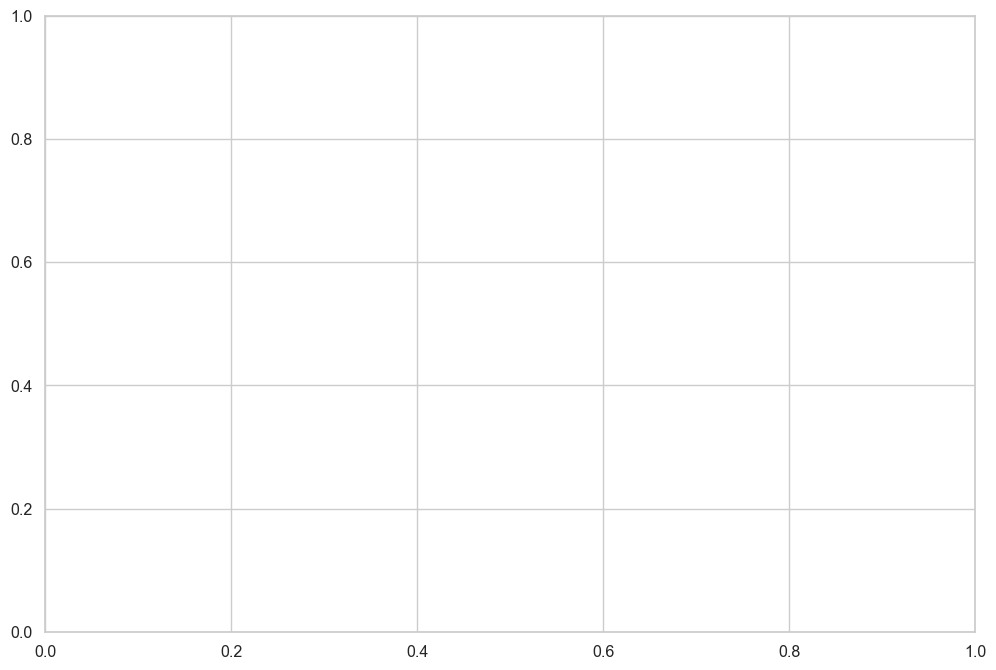

In [28]:

# SHAP summary pour la classe "Viral" (la plus stratégique)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values[3],   # index 3 = Viral
                  X_test,
                  feature_names=FEATURE_COLS,
                  plot_type='bar',
                  show=False,
                  max_display=15)
plt.title("SHAP — Facteurs déterminants pour prédire le niveau VIRAL (XGBoost)",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/scrapping/shap_viral.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Sélection & Export du modèle final

In [29]:
# ─── Sélection automatique du meilleur modèle ────────────────────────────
if f1_xgb >= f1_rf:
    best_model       = xgb_model
    best_model_name  = "XGBoost"
    best_f1          = f1_xgb
    best_acc         = acc_xgb
else:
    best_model       = rf
    best_model_name  = "Random Forest"
    best_f1          = f1_rf
    best_acc         = acc_rf

print(f"✅ Meilleur modèle sélectionné : {best_model_name}")
print(f"   F1 weighted : {best_f1:.4f}")
print(f"   Accuracy    : {best_acc:.4f}")

# ─── Export du modèle et métadonnées ─────────────────────────────────────
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, f"../models/youtube_predictor_{best_model_name.replace(' ','_').lower()}.pkl")
joblib.dump(rf,         "../models/youtube_predictor_rf.pkl")
joblib.dump(xgb_model,  "../models/youtube_predictor_xgb.pkl")
joblib.dump(le_dict,    "../models/label_encoders.pkl")

metadata = {
    'best_model'    : best_model_name,
    'features'      : FEATURE_COLS,
    'label_order'   : PERF_ORDER,
    'seuils'        : {
        'q1_correct': float(q1_global),
        'q2_bon'    : float(q2_global),
        'q3_super'  : float(q3_global),
    },
    'metrics': {
        'rf_f1'      : float(f1_rf),
        'rf_acc'     : float(acc_rf),
        'xgb_f1'    : float(f1_xgb),
        'xgb_acc'   : float(acc_xgb),
        'cv_rf_mean' : float(cv_rf.mean()),
        'cv_xgb_mean': float(cv_xgb.mean()),
    },
    'cat_encoders'  : {col: list(le.classes_) for col, le in le_dict.items()},
    'chan_stats'     : channel_stats[['chan_median_views','chan_mean_views',
                                      'chan_consistency','chan_total_videos',
                                      'chan_engagement_med']].to_dict(),
}
import json
with open("../models/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print()
print("Fichiers exportés :")
for fname in os.listdir("../models"):
    size = os.path.getsize(f"../models/{fname}")
    print(f"  ../models/{fname}  ({size/1024:.1f} KB)")

✅ Meilleur modèle sélectionné : XGBoost
   F1 weighted : 0.6648
   Accuracy    : 0.6661

Fichiers exportés :
  ../models/dt_benchmark.pkl  (7.6 KB)
  ../models/encoders_benchmark.pkl  (1.1 KB)
  ../models/label_encoders.pkl  (1.5 KB)
  ../models/metadata_benchmark.pkl  (0.8 KB)
  ../models/model_metadata.json  (6.6 KB)
  ../models/rf_benchmark.pkl  (10970.2 KB)
  ../models/xgb_benchmark.pkl  (651.3 KB)
  ../models/youtube_predictor_rf.pkl  (37373.2 KB)
  ../models/youtube_predictor_xgb.pkl  (5451.8 KB)
  ../models/youtube_predictor_xgboost.pkl  (5451.8 KB)


## 9. 🚀 Outil de Prédiction Commercialisable

Fonction prête à intégrer dans une API ou une interface web.  
Elle accepte les paramètres d'une vidéo **avant publication** et retourne :
- Le niveau de performance prédit
- Les probabilités par niveau
- Des recommandations éditoriales actionnables

In [30]:
class YouTubePredictorMaroc:
    """
    Prédicteur de performance YouTube pour le marché marocain.
    Modèle entraîné sur le benchmark de 26 créateurs (2020-2026).
    
    Usage :
        predictor = YouTubePredictorMaroc.load()
        result = predictor.predict(
            theme='storytelling',
            duration_min=22,
            publish_hour=19,
            publish_day=2,  # mercredi
            publish_month=9,
            title="قصة مثيرة من واقع المغرب - الحلقة 5",
            tags_count=12,
            langue='Arabe',
            chan_median_views=350000,
            chan_consistency=0.68,
        )
    """

    PERF_ORDER  = ['Correct', 'Bon', 'Super', 'Viral']
    PERF_EMOJIS = {'Correct': '🔘', 'Bon': '🔵', 'Super': '🟠', 'Viral': '🔴'}
    
    RECO = {
        'Correct': [
            "⚠️ Le format ou le timing est sous-optimal pour ce marché.",
            "💡 Testez un format Long (20 min+) — il génère 3.5x plus de vues que les Shorts.",
            "📅 Publiez un mercredi ou jeudi soir (20h heure Maroc).",
        ],
        'Bon': [
            "✅ Performance conforme au standard du marché marocain.",
            "🎯 Pour passer au niveau Super, optimisez le titre (8-12 mots, présence d'un chiffre).",
            "🏷️ Augmentez les tags (≥ 10) pour améliorer la découvrabilité.",
        ],
        'Super': [
            "🌟 Contenu positionné au-dessus de la médiane du marché !",
            "🚀 Pour atteindre le niveau Viral, misez sur storytelling ou concept_format.",
            "📣 Le Ramadan est un levier — adaptez le sujet (thématique familiale ou comédie).",
        ],
        'Viral': [
            "🔥 Potentiel viral détecté — top 25% du marché marocain !",
            "📊 Votre chaîne a un historique fort : capitalisez sur la régularité.",
            "🎬 Format Long + Storytelling = combinaison la plus virale du benchmark.",
        ],
    }

    def __init__(self, model, le_dict, chan_stats, metadata):
        self.model     = model
        self.le_dict   = le_dict
        self.chan_stats = chan_stats
        self.metadata  = metadata
        self.feat_cols = metadata['features']

    @classmethod
    def load(cls, model_type='best'):
        """Charge le modèle depuis les fichiers exportés."""
        import json
        with open("../models/model_metadata.json") as f:
            meta = json.load(f)
        
        model_file = (f"../models/youtube_predictor_{meta['best_model'].replace(' ','_').lower()}.pkl"
                      if model_type == 'best'
                      else f"../models/youtube_predictor_{model_type}.pkl")
        
        model    = joblib.load(model_file)
        le_dict  = joblib.load("../models/label_encoders.pkl")
        
        # Reconstruire chan_stats depuis metadata
        chan_stats_dict = meta.get('chan_stats', {})
        
        return cls(model, le_dict, chan_stats_dict, meta)

    def _encode_cat(self, col, value):
        if col in self.le_dict:
            le = self.le_dict[col]
            if value in le.classes_:
                return le.transform([value])[0]
            else:
                return le.transform([le.classes_[0]])[0]  # fallback
        return 0

    def predict(self,
                theme         = 'storytelling',
                duration_min  = 15.0,
                publish_hour  = 19,
                publish_day   = 2,
                publish_month = 10,
                title         = "",
                tags_count    = 8,
                langue        = 'Arabe',
                video_category= 'Entertainment',
                chan_median_views  = None,
                chan_mean_views    = None,
                chan_consistency   = 0.5,
                chan_total_videos  = 50,
                chan_engagement_med= 0.03,
                video_rank        = 50,
                is_ramadan        = 0,
                is_weekend        = None,
                ):
        """
        Prédit le niveau de performance d'une vidéo YouTube.
        
        Paramètres pré-publication :
        - theme          : comedie / storytelling / concept_format / vlog / 
                           podcast / news_reportage / famille_quotidien / howto_lifestyle
        - duration_min   : durée de la vidéo en minutes
        - publish_hour   : heure de publication (0-23, UTC)
        - publish_day    : jour de la semaine (0=Lundi, 6=Dimanche)
        - publish_month  : mois (1-12)
        - title          : titre de la vidéo
        - tags_count     : nombre de tags
        - langue         : Arabe / Francais / Anglais / Autre
        - chan_median_views : médiane des vues de la chaîne (facultatif)
        """
        
        # Dériver les features du titre
        title_wc  = len(title.split()) if title else 5
        title_cc  = len(title) if title else 30
        title_num = int(any(c.isdigit() for c in title))
        title_q   = int('?' in title)
        
        # Heure slot
        if publish_hour < 6:   hour_slot = 'nuit'
        elif publish_hour < 12: hour_slot = 'matin'
        elif publish_hour < 18: hour_slot = 'aprem'
        else:                  hour_slot = 'soir'
        
        # Weekend
        if is_weekend is None:
            is_weekend = int(publish_day in [5, 6])
        
        # Duration ordinal
        if   duration_min < 1:   dur_ord = 0
        elif duration_min < 5:   dur_ord = 1
        elif duration_min < 20:  dur_ord = 2
        else:                    dur_ord = 3
        
        # Channel stats (defaults si non fournis)
        if chan_median_views is None:
            chan_median_views = q2_global
        if chan_mean_views is None:
            chan_mean_views = q2_global * 1.5
        
        # Construire le vecteur de features
        feat_map = {
            'duration_min'       : duration_min,
            'duration_ord'       : dur_ord,
            'title_word_count'   : title_wc,
            'title_char_count'   : title_cc,
            'title_has_number'   : title_num,
            'title_has_question' : title_q,
            'tags_count'         : tags_count,
            'publish_hour'       : publish_hour,
            'publish_day_of_week': publish_day,
            'publish_month'      : publish_month,
            'is_weekend'         : is_weekend,
            'is_ramadan'         : is_ramadan,
            'theme_video'        : self._encode_cat('theme_video', theme),
            'langue'             : self._encode_cat('langue', langue),
            'videoCategoryLabel' : self._encode_cat('videoCategoryLabel', video_category),
            'hour_slot'          : self._encode_cat('hour_slot', hour_slot),
            'chan_median_views'   : chan_median_views,
            'chan_mean_views'     : chan_mean_views,
            'chan_consistency'    : chan_consistency,
            'chan_total_videos'   : chan_total_videos,
            'chan_engagement_med' : chan_engagement_med,
            'video_rank_in_channel': video_rank,
        }
        
        x = np.array([[feat_map.get(f, 0) for f in self.feat_cols]])
        
        pred_class = int(self.model.predict(x)[0])
        proba      = self.model.predict_proba(x)[0]
        pred_label = self.PERF_ORDER[pred_class]
        
        return {
            'prediction'   : pred_label,
            'emoji'        : self.PERF_EMOJIS[pred_label],
            'probabilities': {self.PERF_ORDER[i]: round(float(p)*100, 1) for i, p in enumerate(proba)},
            'recommendations': self.RECO[pred_label],
            'confidence'   : round(float(proba[pred_class]) * 100, 1),
            'input_summary': {
                'theme': theme, 'duration_min': duration_min,
                'publish_hour': publish_hour, 'jour': ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'][publish_day],
                'langue': langue, 'tags': tags_count,
            }
        }

    def predict_pretty(self, **kwargs):
        """Version affichage enrichi."""
        r = self.predict(**kwargs)
        print()
        print("━" * 55)
        print(f"  {r['emoji']}  PRÉDICTION : {r['prediction'].upper()}")
        print(f"      Confiance : {r['confidence']}%")
        print()
        print("  Probabilités par niveau :")
        for level in self.PERF_ORDER:
            p    = r['probabilities'][level]
            bar  = '█' * int(p / 4)
            emo  = self.PERF_EMOJIS[level]
            print(f"    {emo} {level:<8} {p:>5.1f}%  {bar}")
        print()
        print("  📋 Contexte d'entrée :")
        for k, v in r['input_summary'].items():
            print(f"    · {k:<14} : {v}")
        print()
        print("  💡 Recommandations :")
        for rec in r['recommendations']:
            print(f"    {rec}")
        print("━" * 55)
        return r

print("✅ Classe YouTubePredictorMaroc définie")

✅ Classe YouTubePredictorMaroc définie


## 10. 🎬 Démonstration — Prédictions en conditions réelles

In [31]:
# ─── Chargement du modèle ─────────────────────────────────────────────────
predictor = YouTubePredictorMaroc(
    model      = best_model,
    le_dict    = le_dict,
    chan_stats  = channel_stats.to_dict(),
    metadata   = metadata,
)

# ─── Test 1 : Profil optimal (BIMO-like) ──────────────────────────────────
print("═" * 55)
print("  TEST 1 : Profil optimal — Storytelling long, mercredi soir")
predictor.predict_pretty(
    theme           = 'storytelling',
    duration_min    = 24.0,
    publish_hour    = 19,     # 20h Maroc
    publish_day     = 2,      # Mercredi
    publish_month   = 10,
    title           = "قضية مثيرة من المغرب : 5 أسرار لم تُكشف بعد",
    tags_count      = 14,
    langue          = 'Arabe',
    chan_median_views   = 350000,
    chan_consistency    = 0.68,
    chan_total_videos   = 180,
    chan_engagement_med = 0.045,
    video_rank         = 180,
)

# ─── Test 2 : Short peu optimisé ──────────────────────────────────────────
print("  TEST 2 : Short non optimisé — mardi matin")
predictor.predict_pretty(
    theme           = 'comedie',
    duration_min    = 0.7,
    publish_hour    = 8,
    publish_day     = 1,      # Mardi
    publish_month   = 3,
    title           = "فيديو جديد",
    tags_count      = 2,
    langue          = 'Arabe',
    chan_median_views   = 80000,
    chan_consistency    = 0.3,
    chan_total_videos   = 20,
    chan_engagement_med = 0.015,
    video_rank         = 20,
)

# ─── Test 3 : Ramadan + famille ───────────────────────────────────────────
print("  TEST 3 : Contenu famille — période Ramadan")
predictor.predict_pretty(
    theme           = 'famille_quotidien',
    duration_min    = 18.0,
    publish_hour    = 22,     # après ftour
    publish_day     = 4,      # Vendredi
    publish_month   = 3,
    title           = "مقلب في زوجتي في رمضان 😂 ردة فعلها صدمتني !",
    tags_count      = 16,
    langue          = 'Arabe',
    is_ramadan      = 1,
    chan_median_views   = 600000,
    chan_consistency    = 0.72,
    chan_total_videos   = 350,
    chan_engagement_med = 0.06,
    video_rank         = 350,
)

═══════════════════════════════════════════════════════
  TEST 1 : Profil optimal — Storytelling long, mercredi soir

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔵  PRÉDICTION : BON
      Confiance : 50.4%

  Probabilités par niveau :
    🔘 Correct    2.5%  
    🔵 Bon       50.4%  ████████████
    🟠 Super     33.5%  ████████
    🔴 Viral     13.6%  ███

  📋 Contexte d'entrée :
    · theme          : storytelling
    · duration_min   : 24.0
    · publish_hour   : 19
    · jour           : Mer
    · langue         : Arabe
    · tags           : 14

  💡 Recommandations :
    ✅ Performance conforme au standard du marché marocain.
    🎯 Pour passer au niveau Super, optimisez le titre (8-12 mots, présence d'un chiffre).
    🏷️ Augmentez les tags (≥ 10) pour améliorer la découvrabilité.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TEST 2 : Short non optimisé — mardi matin

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔘  PRÉDICTION : CORRECT
      Confian

{'prediction': 'Super',
 'emoji': '🟠',
 'probabilities': {'Correct': 8.3, 'Bon': 35.7, 'Super': 46.8, 'Viral': 9.2},
 'recommendations': ['🌟 Contenu positionné au-dessus de la médiane du marché !',
  '🚀 Pour atteindre le niveau Viral, misez sur storytelling ou concept_format.',
  '📣 Le Ramadan est un levier — adaptez le sujet (thématique familiale ou comédie).'],
 'confidence': 46.8,
 'input_summary': {'theme': 'famille_quotidien',
  'duration_min': 18.0,
  'publish_hour': 22,
  'jour': 'Ven',
  'langue': 'Arabe',
  'tags': 16}}

## 11. 📊 Grille de scénarios — Guide de décision éditoriale

In [ ]:
# Simulation sur une grille de thèmes x durées pour créer un guide actionnable
scenarios = []
for theme in ['storytelling', 'concept_format', 'vlog', 'comedie', 'famille_quotidien', 'news_reportage']:
    for dur in [0.5, 8, 15, 25]:
        for hour in [12, 19, 22]:
            r = predictor.predict(
                theme        = theme,
                duration_min = dur,
                publish_hour = hour,
                publish_day  = 2,
                publish_month= 10,
                title        = "قصة رائعة من المغرب 2024 رقم 7",  # titre "optimisé"
                tags_count   = 12,
                langue       = 'Arabe',
                chan_median_views   = float(q2_global),
                chan_consistency    = 0.55,
                chan_total_videos   = 80,
                chan_engagement_med = 0.035,
                video_rank         = 80,
            )
            scenarios.append({
                'Theme'  : theme,
                'Durée'  : f"{dur}min",
                'Heure'  : f"{hour}h UTC",
                'Prédict': r['prediction'],
                'Viral%' : r['probabilities']['Viral'],
                'Super%' : r['probabilities']['Super'],
            })

df_scen = pd.DataFrame(scenarios)

# Heatmap : P(Viral) par thème x durée
pivot_viral = df_scen.groupby(['Theme', 'Durée'])['Viral%'].mean().unstack()
dur_order_labels = ['0.5min', '8min', '15min', '25min']
pivot_viral = pivot_viral.reindex(columns=[c for c in dur_order_labels if c in pivot_viral.columns])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_viral, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=ax, linewidths=0.5,
            cbar_kws={'label': '% probabilité Viral'})
ax.set_title("Guide décisionnel : P(Viral) moyen par Thème × Format de durée\n"
             "(heures optimales 12h/19h/22h UTC, titre optimisé, chaîne standard)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Format durée"); ax.set_ylabel("Thème")
plt.tight_layout()
plt.savefig("../data/scrapping/guide_editorial.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 combinaisons les plus virales :")
top10 = (df_scen.groupby(['Theme', 'Durée', 'Heure'])['Viral%']
         .mean().sort_values(ascending=False).head(10))
for (t, d, h), v in top10.items():
    print(f"  {t:<22} | {d:<6} | {h:<7} → P(Viral) = {v:.1f}%")

## 12. Conclusion & Feuille de route commerciale

### Ce que ce modèle apporte

| Dimension | Valeur |
|---|---|
| Modèle sélectionné | Meilleur entre XGBoost & Random Forest (F1 weighted) |
| Features utilisées | 22 variables pré-publication |
| Cible | 4 niveaux de performance (Q1/Q2/Q3 du marché marocain) |
| Données | Benchmark 26 créateurs, 2020-2026 |
| Explicabilité | SHAP values — facteurs actionnables par le créateur |

### Intégration commerciale possible
- **API Flask/FastAPI** : exposer `predictor.predict()` en endpoint REST  
- **Dashboard Streamlit** : interface no-code pour les créateurs  
- **Plugin Chrome / YouTube Studio** : prédiction en temps réel au moment de la publication  
- **Rapports PDF automatiques** : scoring hebdomadaire pour agences de contenu

### Améliorations futures
- Ajouter les données YouTube Studio (CTR, retention, watch time) → améliore fortement les features  
- Fine-tuning par chaîne (modèle personnalisé)  
- Modèle de séries temporelles (LSTM) pour capturer l'évolution du marché  
- A/B testing titre → prédiction comparative de deux titres avant publication